Exploring the dataset

In [26]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import xgboost as xgb
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/willemvandesanden/ESL/esl/.venv/lib/python3.9/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <FBD6AEF9-AFAB-39D7-B881-755157DA0497> /Users/willemvandesanden/ESL/esl/.venv/lib/python3.9/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/usr/local/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/usr/local/opt/libomp/lib/libomp.dylib' (no such file), '/usr/local/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/usr/local/opt/libomp/lib/libomp.d

reading /Users/willemvandesanden/ESL/esl/data/BTCUSDT/processed/dataset_candle.parquet
Shape: (10080, 13)

Columns:
Index(['open', 'high', 'low', 'close', 'volume', 'close_time',
       'quote_asset_volume', 'num_trades', 'taker_buy_base', 'taker_buy_quote',
       'ignore', 'return', 'target'],
      dtype='object')

Head:
                         open      high       low     close     volume  \
2025-12-01 00:01:00  90408.34  90408.34  90300.00  90300.01    9.99673   
2025-12-01 00:02:00  90300.01  90340.25  90278.33  90305.55   31.79438   
2025-12-01 00:03:00  90305.55  90305.55  90194.27  90194.27   57.04552   
2025-12-01 00:04:00  90194.28  90194.28  89510.00  89816.17  503.41775   
2025-12-01 00:05:00  89816.18  89831.89  89522.84  89596.94   76.81928   

                        close_time quote_asset_volume  num_trades  \
2025-12-01 00:01:00  1764547319999    903320.73783330        3915   
2025-12-01 00:02:00  1764547379999   2871422.46471110        4932   
2025-12-01 00:03:00  1

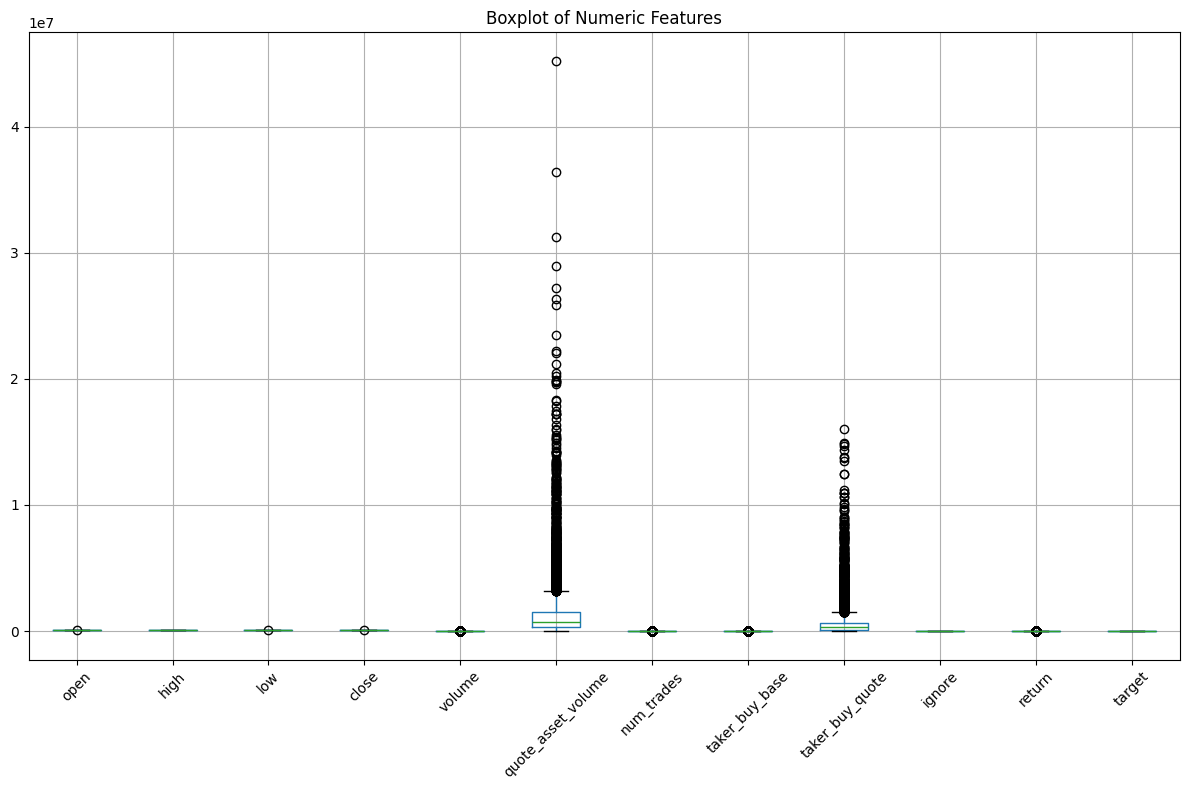

In [27]:
# simplified working path (notebook runs from `notebooks/`)
data_path = Path('..') / 'data' / 'BTCUSDT' / 'processed' / 'dataset_candle.parquet'
print('reading', data_path.resolve())
data = pd.read_parquet(data_path)

print("Shape:", data.shape)
print("\nColumns:")
print(data.columns)

print("\nHead:")
print(data.head())

print("\nMissing values per column:")
print(data.isna().sum())

print("\nNumeric summary:")
print(data.describe())

print("\nCategorical summary:")
print(data.describe(include="object"))

obj_cols = ["quote_asset_volume", "taker_buy_base", "taker_buy_quote", "ignore"]
data[obj_cols] = data[obj_cols].apply(pd.to_numeric, errors="coerce")
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('close_time')
print("\nInfo:")
print(data.info())
plt.figure(figsize=(12, 8))
data[numeric_cols].boxplot()
plt.title("Boxplot of Numeric Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
X = data.drop(columns=['target', 'close_time'])
y = data['target']                                                              

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_train = xgb.DMatrix(X_train, y_train, enable_categorical=True)
xgb_test = xgb.DMatrix(X_test, y_test, enable_categorical=True)

preprocessor_xgboost = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), X_train.columns)
    ],
    remainder="drop"
)